In [1]:
%load_ext autoreload
%autoreload 2
import os
import json
import torch
import pycolmap
import numpy as np
import PIL.Image as Image
import matplotlib.pyplot as plt
import torchvision.transforms as T

from mylib.plot import plot_imgs

In [2]:
# limitations
# -  works best with dense views (accuracy wise)
# - for very few images might not be much faster than BA
# - limited by GPU memory for large scenes
# - occasionally the result is worse than starting result (why?, can we detect this and as fail case?) 

In [3]:
# NETXTS TO DO:
# - find better edges than canny
# to reduce edege, do not randomply exclude, apply non-max suppression or sigma in canny
# improve post-processing of edges in teed


# TODO ROBUSTNESS:
# try to align 3D depth edges with canny edges? so 3D to 2D edge reproj error with DT
# try with straight lines instead of edges?
# mask out edges that do not cycle reproject for each viewgraph pair
# fine-tune an lightweight edge-detector to find edges in the loop 
# cycle consistency loss in forward pass + DT 
    # L_DT = DT(1->2)+DT(2->1)
    # L_cycle = ||1->2->1||_2 + ||2->1->2||_2


# start optimizing only on images with lots of correspondences, then extend to all?
# test more lerned edges methods
# find post processing right method
# optimize K only after convergence? k-t dependency

In [4]:
dataset = "mipnerf360" # terrasky3D, mipnerf360, tt, 7scenes, scannetpp
scene = "room" # vienna_state_opera, bicycle, bonsai, Truck, graz_townhall, graz_main_square, 40aec5fffa

# Load dataset paths and parameters from JSON
with open("benchmarks/paths.json") as f:
    paths_cfg = json.load(f)

dataset_cfg = paths_cfg[dataset]

images_path = os.path.join(
    dataset_cfg["images_path"], scene, dataset_cfg["images_folder"]
)
base_path = dataset_cfg["base_path"]
reconstruction_path = os.path.join(
    base_path, scene, dataset_cfg["reconstruction_folder"]
)
depths_path = os.path.join(
    base_path,
    scene,
    dataset_cfg.get("depths_folder", dataset_cfg.get("depth_folder", "")),
)
gt_path = os.path.join(dataset_cfg["gt_path"], scene, dataset_cfg["gt_folder"])

print("Images path:", images_path)
print("Reconstruction path:", reconstruction_path)
print("Depths path:", depths_path)
print("GT path:", gt_path)

Images path: /home/mattia/Desktop/datasets/mipnerf360/room/images_4_150
Reconstruction path: /home/mattia/Desktop/Repos/batchsfm/benchmarks/vggt/mipnerf360/room/sparse
Depths path: /home/mattia/Desktop/Repos/batchsfm/benchmarks/vggt/mipnerf360/room/sparse/depth_maps
GT path: /home/mattia/Desktop/datasets/mipnerf360/room/sparse_150


In [5]:
from adjuster import Adjuster

adjuster = Adjuster(
    reconstruction_path = reconstruction_path,
    images_path = images_path,
    depths_path = depths_path,
    q_lr=1e-4, grad_q=True,
    t_lr=1e-3, grad_t=True,
    k_lr=1e-3, grad_k=False,
    z_lr=1e-3, grad_z=True,
    use_mlp_pose_refinement=True,
    mlp_pose_lr=1e-3,
    detector="canny",  # or "canny", "bdcn", "sam2", "diff"
    detector_params={"low_threshold":0.20, "high_threshold":0.25, "kernel_size":7, "sigma":2},

    matcher_type="exhaustive",
    viz=True,
    use_amp=False, # at some point I will fix amp implementation
    verbose=True,
    max_edges_points=1024*12,
    max_viewgraph_pairs=1024*4,
)

CannyEdgeDetector initialized with low_threshold=0.2, high_threshold=0.25, hysteresis=True, kernel_size=7, sigma=2, device=cuda
Found 150 images in /home/mattia/Desktop/datasets/mipnerf360/room/images_4_150


Loading images: 100%|██████████| 150/150 [00:00<00:00, 517.13it/s]


When using MLP pose refinement, q and t gradients are disabled.


Extracting edges: 100%|██████████| 150/150 [00:00<00:00, 160.93it/s]


Edges stats:
 15 images have more than 9,197 edges. 
 max: 11,853 | min: 827 | avg: 6,993 | std: 1,907.02 | quantiles (0.5, 0.9): 6,998, 9,197


Filtering viewgraph: 100%|██████████| 22/22 [00:00<00:00, 37.52it/s]


Filtered viewgraph: 4,800/11,175 pairs retained
tensor([[[517., 344.]]], device='cuda:0')

Total parameters to optimize:
  t:                0
  q:                0
  mlp:        269,580
  k:                0
  z:          280,321
-----------------------
  Total:      549,901



In [6]:
# keys = sorted(list(adjuster.images.keys()))
# print(adjuster.images[keys[0]].keys())

# for i in range(0,150, 10):
#     k = keys[i]
#     rgb = adjuster.images[k]['image'].permute(1,2,0).cpu() if 'image' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).permute(1,2,0).cpu()
#     depth = adjuster.images[k]['depth'].cpu() if 'depth' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
#     edges_map = adjuster.images[k]['edges_map'].cpu() if 'edges_map' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
#     conf = adjuster.images[k]['confidence'].cpu() if 'confidence' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
#     conf = (conf - conf.min()) / (conf.max() - conf.min() + 1e-8)
#     dt_field = adjuster.images[k]['dt_field'].cpu() if 'dt_field' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu()
#     plot_imgs([rgb, depth, edges_map, dt_field, conf], titles=[k, "depth", "edges map", "dt field", "confidence"], figsize=(15,5))

In [ ]:
adjuster(
    batch_size=256, 
    max_steps=1_000,
    logging_=True,
    # debug=True, # tracks the residuals, slightly increases timing
    gt_path=gt_path
)

Processing 4,800 pairs with batch size 256 (20 batches per iteration). Using 9,197 edges per image.
Total points to process per iteration: 44,145,600.



Optimizing the scene:  10%|▉         | 99/1000 [00:28<03:59,  3.76it/s, auc5=74.5635, loss=5.6001]

Pose convergence reached at step 98.


Optimizing the scene:  62%|██████▏   | 620/1000 [03:29<02:02,  3.09it/s, auc5=82.1681, loss=4.6511]

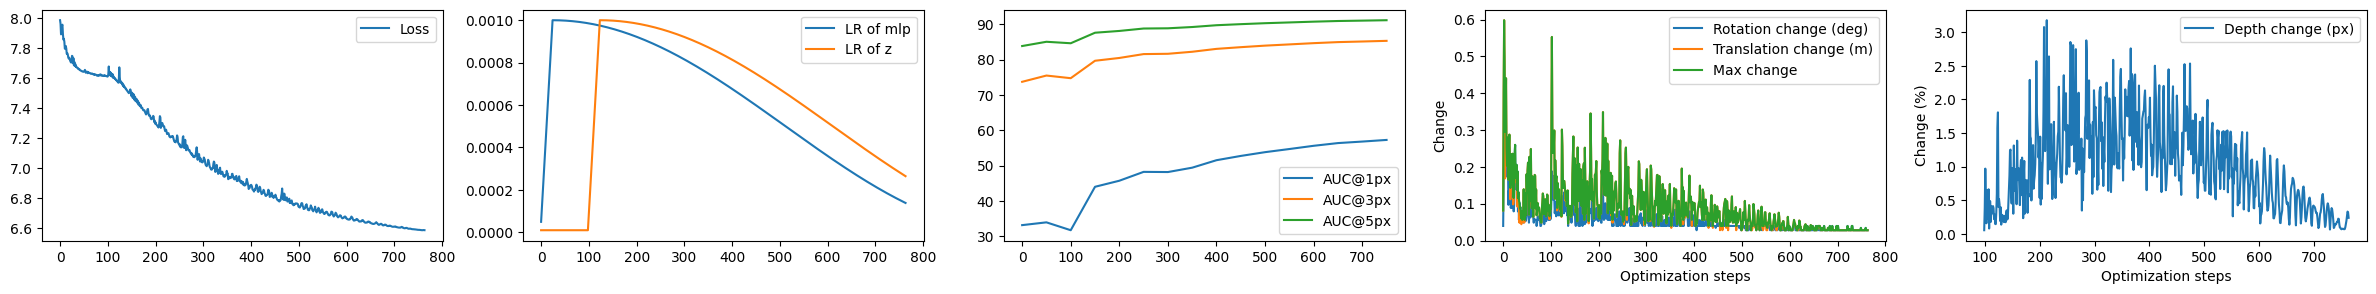

In [ ]:
loss = adjuster.loss_list
lr_list = adjuster.lr_list
auc = adjuster.auc_list['auc']

# plot loss and lr side by side
n_plots = 5
plt.figure(figsize=(n_plots*6,3))
plt.subplot(1, n_plots, 1)
plt.plot(loss, label='Loss')
plt.legend()
plt.subplot(1, n_plots, 2)
for group, lr in lr_list.items():
    lr = np.array(lr)
    if len(lr) > 0:
        steps, lrs = lr[:,0],lr[:,1]
        plt.plot(steps, lrs, label=f'LR of {group}')
        # # print steps when each lr decreased
        # print("Learning rate changes for group", group)
        # for i in range(1, len(lrs)):
        #     if lrs[i] < lrs[i-1]:
        #         print(f"Step {int(steps[i])}: Learning rate decreased from {lrs[i-1]:.1e} to {lrs[i]:.1e}")
plt.legend()
plt.subplot(1, n_plots, 3)
for th in [1,3,5]: #adjuster.auc_th:
    plt.plot(adjuster.auc_list["steps"], auc[th], label=f'AUC@{th}px')
plt.legend() if len(adjuster.auc_list) > 0 else None
plt.subplot(1, n_plots, 4)
plt.plot(adjuster.changes["steps"], adjuster.changes["q"], label='Rotation change (deg)')
plt.plot(adjuster.changes["steps"], adjuster.changes["t"], label='Translation change (m)')
plt.plot(adjuster.changes["steps"], adjuster.changes["max"], label='Max change')
plt.xlabel('Optimization steps')
plt.ylabel('Change')
plt.legend()
plt.subplot(1, n_plots, 5)
plt.plot(adjuster.changes["steps"][-len(adjuster.changes["z"]):], np.array(adjuster.changes["z"])*100, label='Depth change (px)')
plt.xlabel('Optimization steps')
plt.ylabel('Change (%)')
plt.legend()
plt.show()

In [ ]:
# plt.plot(adjuster.changes["steps"], adjuster.changes["q"], label='Rotation change (deg)')
# plt.plot(adjuster.changes["steps"], adjuster.changes["t"], label='Translation change (m)')
# plt.plot(adjuster.changes["steps"], adjuster.changes["max"], label='Max change', linestyle='--')

# # plot a smoothed version
# window_size = 50
# smoothed_max = np.convolve(adjuster.changes["max"], np.ones(window_size)/window_size, mode='valid')
# smoothed_steps = adjuster.changes["steps"][window_size-1:]
# plt.plot(smoothed_steps, smoothed_max, label='Smoothed Max change', color='black', linewidth=2)

# # find step such what smoothed steps are below 0.5 for 10 consecutive steps
# th = 0.5
# steps = 50
# for i in range(len(smoothed_max)-steps):
#     if all(smoothed_max[i+j] < th for j in range(steps)):
#         print(f"Stopping criterion met at step {smoothed_steps[i]} with smoothed max change {smoothed_max[i]:.4f}")
#         # break


# plt.hlines(y=th, xmin=smoothed_steps[0], xmax=smoothed_steps[-1], colors='red', linestyles='dashed')

# plt.xlabel('Optimization steps')
# plt.ylabel('Change')
# plt.legend()
# plt.show()

In [ ]:
opt = f"/home/mattia/Desktop/Repos/batchsfm/optimized_reconstruction_GD/{scene}"
os.makedirs(opt, exist_ok=True)

save_points = False

adjuster.to_colmap(
    opt, 
    verbose=False, 
    max_points_per_image=100_000//len(adjuster.images), 
    save_points=save_points, 
    final_dbscan_filtering=False, 
    dbscan_eps=0.1, dbscan_min_samples=5
)

Reconstruction(num_cameras=1, num_images=150, num_reg_images=150, num_points3D=0)

In [ ]:
import sys
sys.path.append('/home/mattia/Desktop/Repos/posebench/benchmarks_3D')
from benchmark_pose import eval_colmap_model

thresholds = [1,3,5]
print("AUC@",thresholds)
AUC_score_max, num_images, df_initial = eval_colmap_model(reconstruction_path, gt_path, return_df=True, thrs=thresholds)
print("VGGT AUC:   ", AUC_score_max)

try:
    ba = reconstruction_path.replace("vggt", "vggt_ba")
    AUC_score_max, num_images, df_ba = eval_colmap_model(ba, gt_path, return_df=True, thrs=thresholds)
    print("VGGT+BA AUC:", AUC_score_max)
except:
    df_ba = None
    print("No BA reconstruction found.")
    
AUC_score_max, num_images, df_optim = eval_colmap_model(opt, gt_path, return_df=True, thrs=thresholds)
print("VGGT+EA AUC:", AUC_score_max)
print(f"Best AUC@5: at {np.argmax(auc[5])*50}", [max(auc[5])])

AUC@ [1, 3, 5]
VGGT AUC:    [32.24887007 73.36660953 83.63521168]
VGGT+BA AUC: [49.96609761 83.19360127 89.9152618 ]
VGGT+EA AUC: [57.33499682 85.3456398  91.17771327]
Best AUC@5: at 750 [91.16568284685778]


In [ ]:
# check cameras too
import pycolmap

gt_cameras = pycolmap.Reconstruction(gt_path).cameras
vggt_cameras = pycolmap.Reconstruction(reconstruction_path).cameras
ba_cameras = pycolmap.Reconstruction(ba).cameras if df_ba is not None else None
optim_cameras = pycolmap.Reconstruction(opt).cameras

print("Cameras comparison:")
print("gt:", gt_cameras)
print("vggt:", vggt_cameras)
if ba_cameras is not None:
    print("ba:", ba_cameras)
print("edge:", optim_cameras)

Cameras comparison:
gt: MapCameraIdToCamera{1: Camera(camera_id=1, model=PINHOLE, width=778, height=519, params=[797.451, 797.404, 389, 259.25] (fx, fy, cx, cy))}
vggt: MapCameraIdToCamera{150: Camera(camera_id=150, model=PINHOLE, width=779, height=519, params=[799.737, 799.616, 389.5, 259.5] (fx, fy, cx, cy)), 149: Camera(camera_id=149, model=PINHOLE, width=779, height=519, params=[800.474, 799.678, 389.5, 259.5] (fx, fy, cx, cy)), 148: Camera(camera_id=148, model=PINHOLE, width=779, height=519, params=[797.518, 796.511, 389.5, 259.5] (fx, fy, cx, cy)), 147: Camera(camera_id=147, model=PINHOLE, width=779, height=519, params=[800.598, 800.337, 389.5, 259.5] (fx, fy, cx, cy)), 146: Camera(camera_id=146, model=PINHOLE, width=779, height=519, params=[795.203, 794.064, 389.5, 259.5] (fx, fy, cx, cy)), 145: Camera(camera_id=145, model=PINHOLE, width=779, height=519, params=[792.545, 791.214, 389.5, 259.5] (fx, fy, cx, cy)), 144: Camera(camera_id=144, model=PINHOLE, width=779, height=519, pa

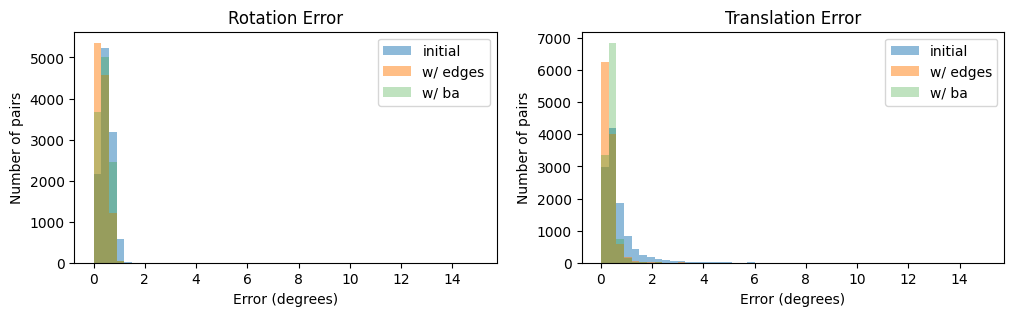

In [ ]:
if True:
    bins = min(50, len(df_initial)//5)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,3))
    plt.subplot(1,2,1)
    plt.hist(df_initial.q_error, bins=bins, range=(0,15), alpha=0.5, label='initial')
    plt.hist(df_optim.q_error, bins=bins, range=(0,15), alpha=0.5, label='w/ edges')
    try:
        plt.hist(df_ba.q_error, bins=bins, range=(0,15), alpha=0.3, label='w/ ba')
    except:
        pass
    plt.title('Rotation Error')
    plt.xlabel('Error (degrees)')
    plt.ylabel('Number of pairs')
    plt.legend()
    plt.subplot(1,2,2)
    plt.hist(df_initial.t_error, bins=bins, range=(0,15), alpha=0.5, label='initial')
    plt.hist(df_optim.t_error, bins=bins, range=(0,15), alpha=0.5, label='w/ edges')
    try:
        plt.hist(df_ba.t_error, bins=bins, range=(0,15), alpha=0.3, label='w/ ba')
    except:
        pass
    plt.title('Translation Error')
    plt.xlabel('Error (degrees)')
    plt.ylabel('Number of pairs')
    plt.legend()
    plt.show()

In [ ]:
# import torch
# residuals_0 = torch.tensor(list(adjuster.residuals[0].values()))
# residuals_final = torch.tensor(list(adjuster.residuals[-1].values()))

# # print infos about residuals
# print(f"Initial residuals ({len(residuals_0)}): mean={residuals_0.mean():.3f}, std={residuals_0.std():.3f}, min={residuals_0.min():.3f}, max={residuals_0.max():.3f}")
# print(f"Final residuals   ({len(residuals_final)}): mean={residuals_final.mean():.3f}, std={residuals_final.std():.3f}, min={residuals_final.min():.3f}, max={residuals_final.max():.3f}")

# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# out_initial = plt.hist(residuals_0, bins=100, alpha=0.7, label='initial')
# # find valus for vlines
# plt.vlines(residuals_0.mean(), 0, out_initial[0].max(), colors='r', linestyles='dashed', label='mean initial')
# plt.title('Initial Residuals Distribution')
# plt.xlabel('Residual')
# plt.ylabel('Number of pairs')
# plt.legend()
# plt.subplot(1,2,2)
# out_final = plt.hist(residuals_final, bins=100, alpha=0.7, label='final')
# plt.vlines(residuals_0.mean(), 0, out_initial[0].max(), colors='r', linestyles='dashed', label='mean initial')
# plt.vlines(residuals_final.mean(), 0, out_final[0].max(), colors='g', linestyles='dashed', label='mean final')
# plt.title('Final Residuals Distribution')
# plt.xlabel('Residual')
# plt.ylabel('Number of pairs')
# plt.legend()
# plt.show()

In [ ]:
# adjuster.visualize_residuals(custom_viewgraph=adjuster.viewgraph[::100], output_dir=opt+"/residuals_viz")

In [ ]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

## 2D Visualisation

In [ ]:
from mylib.plot import plot_imgs

viewgraph = adjuster.viewgraph
images = adjuster.images
intrinsics = adjuster.intrinsics
poses = adjuster.poses

print(len(viewgraph))

In [ ]:
for k, (i, j) in enumerate(adjuster.valid_points_per_pair):
    print(k, i, j, adjuster.valid_points_per_pair[(i,j)])

In [ ]:
(i,j) = viewgraph[16]
c = adjuster.valid_points_per_pair[(i,j)]
print(i, j, c)

# i, j =  '13/IMG_4697_frame_000001.jpg', '13/IMG_4697_frame_000007.jpg'

plot_imgs([images[i]['image'].permute(1,2,0).cpu(), images[i]['edges_map'].cpu(),images[i]['depth'].cpu(),
           images[j]['image'].permute(1,2,0).cpu(), images[j]['edges_map'].cpu(),images[j]['depth'].cpu()], 
           titles=[f"Image {i}", "Edges", "Depth", f"Image {j}", "Edges", "Depth"],
           cmap=[None, "gray","plasma"]*2, rows=2, figsize=(12,6))

In [ ]:
x1,y1,x2,y2,h,w = [int(x) for x in images[i]['coords']]
img1 = images[i]['image'][:, y1:y2, x1:x2]
img2 = images[j]['image'][:, y1:y2, x1:x2]
Z1 = images[i]['depth'][None]  # Full depth, not cropped
Z2 = images[j]['depth'][None]  # Full depth, not cropped

In [ ]:
# Debug shapes and values
print(f"P0 shape: {poses.get_projection_matrix(i)[:1].shape}")
print(f"K0 shape: {intrinsics.get_intrinsic_matrix(images[i]['cam_id']).shape}")
print(f"Z1 shape: {Z1.shape}, min: {Z1[~torch.isnan(Z1)].min() if (~torch.isnan(Z1)).any() else 'all NaN'}")
print(f"Z2 shape: {Z2.shape}, min: {Z2[~torch.isnan(Z2)].min() if (~torch.isnan(Z2)).any() else 'all NaN'}")
print(f"img1 shape: {img1.shape}, img2 shape: {img2.shape}")

# Check valid depth percentage
valid_z1 = (~torch.isnan(Z1) & (Z1 > 0)).sum() / Z1.numel() * 100
valid_z2 = (~torch.isnan(Z2) & (Z2 > 0)).sum() / Z2.numel() * 100
print(f"Valid depth Z1: {valid_z1:.1f}%, Z2: {valid_z2:.1f}%")

In [ ]:
from helpers.reprojection import compute_121_reprojection
from mylib.plot import plot_imgs_and_kpts

data = {
    'P0': poses.get_projection_matrix(i)[:1],
    'P1': poses.get_projection_matrix(j)[:1],
    'K0': intrinsics.get_intrinsic_matrix(images[i]['cam_id']),
    'K1': intrinsics.get_intrinsic_matrix(images[j]['cam_id']),
    'depth0': Z1,
    'depth1': Z2
}

# Use same parameters as adjuster (for frustums matcher)
with torch.no_grad():
    kpts1, kpts2, tot = compute_121_reprojection(
        data,
        images[i]['image'],  # Full image
        images[j]['image'],  # Fix: use img2, not img1
        verbose=False,
        reprojection_error=3,
        border=10,
        sampling_factor=5
    )
    kpts1, kpts2 = kpts1.squeeze(), kpts2.squeeze()

print(f"Adjuster valid points: {adjuster.valid_points_per_pair.get((i,j), 'N/A')}")
print(f"Manual computation: {len(kpts1):,} out of {tot:,} ({100*len(kpts1)/tot:.1f}%)")

# Visualize on full images
plot_imgs_and_kpts(
    images[i]['image'].permute(1,2,0).cpu()*255//1,
    images[j]['image'].permute(1,2,0).cpu()*255//1,
    kpts1.detach().cpu(), kpts2.detach().cpu(),
    sample_points=-1, matches=False,
)

In [ ]:
edge1 = images[i]['edges_map'][y1:y2, x1:x2]
edge2 = images[j]['edges_map'][y1:y2, x1:x2]
edge1_kpts = edge1.nonzero().flip(dims=(0,1))
edge2_kpts = edge2.nonzero().flip(dims=(0,1))

print(edge1_kpts.shape, edge2_kpts.shape)

plot_imgs_and_kpts(
    edge1[..., None].repeat(1,1,3).cpu()*255//1,
    edge2[..., None].repeat(1,1,3).cpu()*255//1,
    edge2_kpts, edge1_kpts,
    sample_points=-1, matches=False,
) 

In [ ]:
from losses.dt_loss import sample_distance_field

dist = sample_distance_field(images[j]['dt_field'][None], images[i]['edges'] [None]).cpu()
print(f"Loss: {dist.mean():.4f}, dist length: {len(dist):,}, edges length: {len(images[i]['edges']):,}")

field = torch.zeros_like(images[j]['dt_field']).cpu()
edges = images[i]['edges'].long()
dist = dist.flatten()  # Ensure it's 1D

for idx, pt in enumerate(edges):
    field[pt[1].item(), pt[0].item()] = dist[idx].item()

plt.figure(figsize=(16,10))
plt.imshow(field, cmap="magma")
# plt.scatter(images[i]['edges'][:,0].cpu(), images[i]['edges'][:,1].cpu(), s=1, c='cyan')
plt.show()

In [ ]:
.

## (Non working) 3D Visualization

In [ ]:
import torch
import numpy as np
import plotly.graph_objects as go
import pycolmap
from pytorch3d.renderer import SfMPerspectiveCameras
from pytorch3d.structures import Pointclouds
from pytorch3d.transforms import quaternion_to_matrix

# --- 1. Setup Device ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 2. Helper Functions ---

def get_camera_wireframe_tensor(scale: float = 0.3):
    """
    Returns a wireframe of a camera frustum.
    """
    # Vertex definitions for a simple frustum
    # PyTorch3D / OpenGL convention: +Z is forward, +Y is up, +X is left
    a = 0.5 * torch.tensor([-2, 1.5, 4])
    up1 = 0.5 * torch.tensor([0, 1.5, 4])
    up2 = 0.5 * torch.tensor([0, 2, 4])
    b = 0.5 * torch.tensor([2, 1.5, 4])
    c = 0.5 * torch.tensor([-2, -1.5, 4])
    d = 0.5 * torch.tensor([2, -1.5, 4])
    C = torch.zeros(3) # Camera Center
    F = torch.tensor([0, 0, 3]) # Forward direction tip
    
    camera_points = [a, up1, up2, up1, b, d, c, a, C, b, d, C, c, C, F]
    lines = torch.stack([x.float() for x in camera_points]) * scale
    return lines

def float_color_to_css(color_list):
    rgb = [int(c * 255) for c in color_list]
    return f"rgb({rgb[0]}, {rgb[1]}, {rgb[2]})"

def qvec2rotmat(qvec):
    """
    Manual conversion from COLMAP Quaternion [w, x, y, z] to Rotation Matrix.
    """
    return np.array([
        [1 - 2 * qvec[2]**2 - 2 * qvec[3]**2,
         2 * qvec[1] * qvec[2] - 2 * qvec[0] * qvec[3],
         2 * qvec[3] * qvec[1] + 2 * qvec[0] * qvec[2]],
        [2 * qvec[1] * qvec[2] + 2 * qvec[0] * qvec[3],
         1 - 2 * qvec[1]**2 - 2 * qvec[3]**2,
         2 * qvec[2] * qvec[3] - 2 * qvec[0] * qvec[1]],
        [2 * qvec[3] * qvec[1] - 2 * qvec[0] * qvec[2],
         2 * qvec[2] * qvec[3] + 2 * qvec[0] * qvec[1],
         1 - 2 * qvec[1]**2 - 2 * qvec[2]**2]])

def load_real_colmap_data(path, device):
    """
    Loads COLMAP data using raw qvec/tvec to be robust against version changes.
    Applies strict Coordinate System conversion for PyTorch3D.
    """
    print(f"Loading COLMAP model from: {path} ...")
    
    try:
        recon = pycolmap.Reconstruction(path)
    except Exception as e:
        raise ValueError(f"Error loading path '{path}'. Ensure it's a valid COLMAP sparse folder. Details: {e}")
    
    # --- A. Process Point Cloud ---
    points3d = recon.points3D
    xyz = []
    rgb = []
    
    for p_id, point in points3d.items():
        xyz.append(point.xyz)
        rgb.append(point.color)
        
    verts = torch.tensor(np.array(xyz), dtype=torch.float32, device=device)
    features = torch.tensor(np.array(rgb), dtype=torch.float32, device=device) / 255.0
    point_cloud = Pointclouds(points=[verts], features=[features])

    # --- B. Process Cameras (Extrinsics) ---
    images = recon.images
    
    R_list = []
    T_list = []
    
    # Sort by image name for logical trajectory lines
    sorted_image_keys = sorted(images.keys(), key=lambda k: images[k].name)
    
    # Coordinate Fix:
    # COLMAP (OpenCV): +X Right, +Y Down, +Z Forward
    # PyTorch3D (NDC): +X Left,  +Y Up,   +Z Forward
    # Transform: Flip X and Y axes.
    # We apply this to the World-to-View matrix.
    coord_fix = torch.tensor([
        [ 1.0,  0.0,  0.0],
        [ 0.0,  1.0,  0.0],
        [ 0.0,  0.0,  -1.0]
    ], device=device, dtype=torch.float32)
    
    for img_id in sorted_image_keys:
        img = images[img_id]
        
        # 1. robustly get qvec and tvec (works on all pycolmap versions)
        R_np = img.cam_from_world.rotation.matrix()
        tvec = img.cam_from_world.translation
        
        # 2. Convert to rotation matrix (numpy -> torch)
        R_raw = torch.from_numpy(R_np).float().to(device)
        T_raw = torch.from_numpy(tvec).float().to(device)
        
        # 3. Apply the coordinate fix
        # New_R = Fix @ Old_R
        # New_T = Fix @ Old_T
        R_fixed = coord_fix @ R_raw
        T_fixed = coord_fix @ T_raw  # Matrix-vector multiplication
        
        R_list.append(R_fixed)
        T_list.append(T_fixed)

    if not R_list:
        raise ValueError("No images found in COLMAP data.")

    # Stack
    R = torch.stack(R_list)
    T = torch.stack(T_list)

    # Initialize PyTorch3D Cameras
    cameras = SfMPerspectiveCameras(device=device, R=R, T=T)
    
    print(f" -> Loaded {len(xyz)} points and {len(sorted_image_keys)} cameras.")
    return cameras, point_cloud

# --- 3. Main Visualization Function ---

def visualize_multi_camera_single_pointcloud(model_inputs, cam_scale=0.1):
    fig = go.Figure()
    
    for i, inp in enumerate(model_inputs):
        path = inp['path']
        label = inp['label']
        color_list = inp['color']
        css_color = float_color_to_css(color_list)
        
        # Load
        cameras, point_cloud = load_real_colmap_data(path, device)
        
        # --- A. Draw Point Cloud (First input only) ---
        if i == 0:
            print("Processing Point Cloud...")
            verts = point_cloud.points_packed().detach().cpu().numpy()
            colors = point_cloud.features_packed().detach().cpu().numpy()
            
            # Subsample
            MAX_POINTS = 30_000
            if verts.shape[0] > MAX_POINTS:
                indices = np.random.choice(verts.shape[0], MAX_POINTS, replace=False)
                verts = verts[indices]
                colors = colors[indices]
            
            colors_int = (colors * 255).astype(int)
            colors_str = [f'rgb({r},{g},{b})' for r,g,b in colors_int]
            
            fig.add_trace(go.Scatter3d(
                x=verts[:, 0].tolist(),
                y=verts[:, 1].tolist(),
                z=verts[:, 2].tolist(),
                mode='markers',
                marker=dict(size=1.5, color=colors_str),
                name="Point Cloud"
            ))

        # --- B. Draw Camera Trajectory ---
        print(f"Processing Trajectory: {label}...")
        
        # 1. Get wireframe
        cam_wireframe = get_camera_wireframe_tensor(scale=cam_scale).to(device)
        
        # 2. Transform wireframe to World Space
        # This calculates C = -R.T @ T internally to place cameras correctly
        cam_trans = cameras.get_world_to_view_transform().inverse()
        cam_wires_trans = cam_trans.transform_points(cam_wireframe).detach().cpu()
        
        # 3. Plotly formatting
        n_cams, n_lines, _ = cam_wires_trans.shape
        nan_tensor = torch.full((1, 3), float('nan'))
        
        wires_with_nans = []
        for cam_idx in range(n_cams):
            wires_with_nans.append(cam_wires_trans[cam_idx])
            wires_with_nans.append(nan_tensor)
        
        all_wires_np = torch.cat(wires_with_nans, dim=0).numpy()
        
        fig.add_trace(go.Scatter3d(
            x=all_wires_np[:, 0].tolist(),
            y=all_wires_np[:, 1].tolist(),
            z=all_wires_np[:, 2].tolist(),
            mode='lines',
            line=dict(color=css_color, width=2),
            name=f"{label} Cameras"
        ))

    fig.update_layout(
        title="Reconstruction Visualization",
        height=900,
        width=1200,
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode='data'
        )
    )
    fig.show()

In [ ]:

model_inputs = [
    {
        'path': gt_path,
        'label': 'GT',
        'color': [0.0, 1.0, 0.0] # Green: Cameras
    },
    {
        'path': reconstruction_path,
        'label': 'VGGT Output',
        'color': [1.0, 0.0, 0.0] # Red: Cameras
    },
    {
        'path': ba,
        'label': 'BA',
        'color': [0.0, 0.0, 1.0] # Blue: Cameras
    },
    {
        'path': opt,
        'label': 'EA',
        'color': [0.0, 0.0, 0.0] # Yellow: Cameras
    },
]

# Run the visualization | Not working, coordinates convetion mismatch
# visualize_multi_camera_single_pointcloud(model_inputs, cam_scale=0.25)